<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week2_Day3_Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# ÉTAPE 1 : Chargement et première exploration
# ============================================================

import pandas as pd
import numpy as np
import urllib.request
import zipfile
import os

# ------------------------------------------------------------
# Téléchargement et extraction du dataset
# ------------------------------------------------------------
url = "https://github.com/devtlv/Datasets-DA-Bootcamp-2-/raw/refs/heads/main/W4%20Gen%20AI/W4D3/Airplane%20Crashes%20and%20Fatalities%20upto%202023.zip"
urllib.request.urlretrieve(url, "crashes.zip")

with zipfile.ZipFile("crashes.zip", "r") as zip_ref:
    zip_ref.extractall("crashes_data")

# Lister les fichiers extraits pour identifier le bon fichier à charger
for root, dirs, files in os.walk("crashes_data"):
    for f in files:
        print(os.path.join(root, f))

crashes_data/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv


In [4]:
# ------------------------------------------------------------
# Chargement du fichier avec encodage adapté
# ------------------------------------------------------------
df = pd.read_csv(
    "crashes_data/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv",
    encoding="latin-1"
)

print("=== Aperçu des données ===")
print(df.head())

print(f"\n{df.shape[0]} lignes, {df.shape[1]} colonnes")

print("\n=== Colonnes ===")
print(df.columns.tolist())

print("\n=== Types de données ===")
print(df.dtypes)

print("\n=== Valeurs manquantes (en %) ===")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\n=== Statistiques descriptives (colonnes numériques) ===")
print(df.describe())

=== Aperçu des données ===
        Date   Time                            Location  \
0  9/17/1908  17:18                 Fort Myer, Virginia   
1   9/7/1909    NaN             Juvisy-sur-Orge, France   
2  7/12/1912   6:30           Atlantic City, New Jersey   
3   8/6/1913    NaN  Victoria, British Columbia, Canada   
4   9/9/1913  18:30                  Over the North Sea   

                 Operator Flight #          Route                 AC Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1                     NaN      NaN       Air show          Wright Byplane   
2    Military - U.S. Navy      NaN    Test flight               Dirigible   
3                 Private      NaN            NaN        Curtiss seaplane   
4  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   

  Registration cn/ln  Aboard  Aboard Passangers  Aboard Crew  Fatalities  \
0          NaN     1     2.0                1.0          1.0         1.0   
1  

In [5]:
# ============================================================
# ÉTAPE 1 (suite) : Nettoyage des données
# ============================================================

# ------------------------------------------------------------
# 1) Conversion de la colonne Date en datetime
# ------------------------------------------------------------
# format mixte possible -> on laisse pandas inférer, avec errors='coerce'
# pour transformer les dates invalides en NaT plutôt que de planter
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print("Dates non converties (NaT) :", df['Date'].isnull().sum())
print("Plage de dates :", df['Date'].min(), "à", df['Date'].max())

# ------------------------------------------------------------
# 2) Extraction de features temporelles utiles
# ------------------------------------------------------------
df['Year'] = df['Date'].dt.year
df['Decade'] = (df['Year'] // 10) * 10  # ex: 1987 -> 1980

# ------------------------------------------------------------
# 3) Nettoyage des colonnes numériques clés
# ------------------------------------------------------------
# On ne supprime PAS les lignes avec NaN sur Aboard/Fatalities globalement,
# car ça représente moins de 1% des données et certaines colonnes annexes
# (Flight #, Route) ont énormément de NaN mais ne nous empêchent pas d'analyser
# les fatalités. On gère donc les NaN colonne par colonne, selon l'usage.

# ------------------------------------------------------------
# 4) Calcul du taux de survie par crash
# ------------------------------------------------------------
# Survivants = Aboard - Fatalities (uniquement calculable si les deux sont connus)
df['Survivors'] = df['Aboard'] - df['Fatalities']
df['Survival_Rate'] = df['Survivors'] / df['Aboard']

# Sécurité : un taux de survie ne peut pas être négatif ou > 1
# (cas limites possibles si erreurs de saisie historiques)
df.loc[(df['Survival_Rate'] < 0) | (df['Survival_Rate'] > 1), 'Survival_Rate'] = np.nan

print("\n=== Vérification après nettoyage ===")
print(df[['Date', 'Year', 'Decade', 'Aboard', 'Fatalities', 'Survivors', 'Survival_Rate']].head())
print("\nValeurs manquantes sur Survival_Rate :", df['Survival_Rate'].isnull().sum(),
      f"({df['Survival_Rate'].isnull().mean()*100:.1f}%)")

print("\n=== Répartition des crashs par décennie ===")
print(df['Decade'].value_counts().sort_index())

Dates non converties (NaT) : 0
Plage de dates : 1908-09-17 00:00:00 à 2023-11-01 00:00:00

=== Vérification après nettoyage ===
        Date  Year  Decade  Aboard  Fatalities  Survivors  Survival_Rate
0 1908-09-17  1908    1900     2.0         1.0        1.0            0.5
1 1909-09-07  1909    1900     1.0         1.0        0.0            0.0
2 1912-07-12  1912    1910     5.0         5.0        0.0            0.0
3 1913-08-06  1913    1910     1.0         1.0        0.0            0.0
4 1913-09-09  1913    1910    20.0        14.0        6.0            0.3

Valeurs manquantes sur Survival_Rate : 23 (0.5%)

=== Répartition des crashs par décennie ===
Decade
1900      2
1910     31
1920    182
1930    357
1940    578
1950    649
1960    636
1970    612
1980    552
1990    631
2000    506
2010    235
2020     27
Name: count, dtype: int64


In [6]:
# ============================================================
# ÉTAPE 2 : Exploration statistique de base (EDA)
# ============================================================

# ------------------------------------------------------------
# 1) Statistiques globales
# ------------------------------------------------------------
total_crashes = len(df)
total_fatalities = df['Fatalities'].sum()
total_aboard = df['Aboard'].sum()
overall_survival_rate = (total_aboard - total_fatalities) / total_aboard

print("=== Statistiques globales (1908-2023) ===")
print(f"Nombre total de crashs           : {total_crashes}")
print(f"Nombre total de personnes à bord : {total_aboard:.0f}")
print(f"Nombre total de décès            : {total_fatalities:.0f}")
print(f"Taux de survie global            : {overall_survival_rate*100:.2f}%")

# ------------------------------------------------------------
# 2) Statistiques sur les fatalités par crash
# ------------------------------------------------------------
print("\n=== Fatalités par crash : statistiques descriptives ===")
print(df['Fatalities'].describe())
print(f"\nMédiane : {df['Fatalities'].median()}")
print(f"Skewness (asymétrie) : {df['Fatalities'].skew():.3f}")
# skewness > 0 -> distribution étalée vers la droite (quelques crashs très meurtriers)

# ------------------------------------------------------------
# 3) Évolution du nombre de crashs par année
# ------------------------------------------------------------
crashes_per_year = df.groupby('Year').size()

print("\n=== Années avec le plus de crashs ===")
print(crashes_per_year.sort_values(ascending=False).head(5))

# ------------------------------------------------------------
# 4) Évolution des fatalités par année
# ------------------------------------------------------------
fatalities_per_year = df.groupby('Year')['Fatalities'].sum()

print("\n=== Années avec le plus de fatalités ===")
print(fatalities_per_year.sort_values(ascending=False).head(5))

# ------------------------------------------------------------
# 5) Taux de survie moyen par décennie
# ------------------------------------------------------------
print("\n=== Taux de survie moyen par décennie ===")
print(df.groupby('Decade')['Survival_Rate'].mean().round(3))

=== Statistiques globales (1908-2023) ===
Nombre total de crashs           : 4998
Nombre total de personnes à bord : 155356
Nombre total de décès            : 111644
Taux de survie global            : 28.14%

=== Fatalités par crash : statistiques descriptives ===
count    4990.000000
mean       22.373547
std        35.061741
min         0.000000
25%         4.000000
50%        11.000000
75%        25.000000
max       583.000000
Name: Fatalities, dtype: float64

Médiane : 11.0
Skewness (asymétrie) : 4.607

=== Années avec le plus de crashs ===
Year
1946    88
1989    83
1947    82
1962    77
1948    77
dtype: int64

=== Années avec le plus de fatalités ===
Year
1972    2796.0
1985    2590.0
1973    2323.0
1996    2314.0
1974    2242.0
Name: Fatalities, dtype: float64

=== Taux de survie moyen par décennie ===
Decade
1900    0.250
1910    0.033
1920    0.120
1930    0.168
1940    0.153
1950    0.173
1960    0.173
1970    0.201
1980    0.199
1990    0.218
2000    0.194
2010    0.163
2020

In [7]:
# ============================================================
# ÉTAPE 3 : Analyse statistique avec SciPy
# ============================================================

from scipy import stats

# ------------------------------------------------------------
# 1) Test de normalité sur les fatalités (Shapiro-Wilk)
# ------------------------------------------------------------
# H0 : les données suivent une distribution normale
# On prend un échantillon aléatoire car Shapiro-Wilk devient peu fiable
# au-delà de quelques milliers de points (et lent à calculer)
fatalities_clean = df['Fatalities'].dropna()
sample = fatalities_clean.sample(min(2000, len(fatalities_clean)), random_state=42)

shapiro_stat, shapiro_p = stats.shapiro(sample)
print("=== Test de normalité (Shapiro-Wilk) sur les fatalités ===")
print(f"Statistic : {shapiro_stat:.4f}")
print(f"p-value   : {shapiro_p:.2e}")
if shapiro_p < 0.05:
    print("-> On rejette H0 : la distribution des fatalités N'EST PAS normale.")
else:
    print("-> On ne rejette pas H0 : pas de preuve contre la normalité.")

# ------------------------------------------------------------
# 2) Statistiques clés (mean, median, std) - rappel formel demandé par l'énoncé
# ------------------------------------------------------------
print("\n=== Statistiques clés : Fatalités ===")
print(f"Moyenne     : {fatalities_clean.mean():.2f}")
print(f"Médiane     : {fatalities_clean.median():.2f}")
print(f"Écart-type  : {fatalities_clean.std():.2f}")

survival_clean = df['Survival_Rate'].dropna()
print("\n=== Statistiques clés : Taux de survie ===")
print(f"Moyenne     : {survival_clean.mean():.4f}")
print(f"Médiane     : {survival_clean.median():.4f}")
print(f"Écart-type  : {survival_clean.std():.4f}")

# ------------------------------------------------------------
# 3) Test d'hypothèse : comparaison des fatalités entre décennies (ANOVA)
# ------------------------------------------------------------
# On exclut les décennies 1900 et 2020 : trop peu de données / décennie incomplète
# pour une comparaison équitable (vu à l'étape 2 : 2 et 27 crashs seulement)
decades_to_compare = df[~df['Decade'].isin([1900, 2020])].copy()

decade_groups = [
    group['Fatalities'].dropna()
    for _, group in decades_to_compare.groupby('Decade', observed=True)
]

f_stat, p_value = stats.f_oneway(*decade_groups)

print("\n=== ANOVA : Fatalités par crash selon la décennie ===")
print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_value:.4e}")

if p_value < 0.05:
    print("-> On rejette H0 : le nombre de fatalités par crash diffère significativement selon la décennie.")
else:
    print("-> Pas de preuve statistique suffisante d'une différence selon la décennie.")

=== Test de normalité (Shapiro-Wilk) sur les fatalités ===
Statistic : 0.6044
p-value   : 1.76e-55
-> On rejette H0 : la distribution des fatalités N'EST PAS normale.

=== Statistiques clés : Fatalités ===
Moyenne     : 22.37
Médiane     : 11.00
Écart-type  : 35.06

=== Statistiques clés : Taux de survie ===
Moyenne     : 0.1815
Médiane     : 0.0000
Écart-type  : 0.3117

=== ANOVA : Fatalités par crash selon la décennie ===
F-statistic : 27.6773
p-value     : 4.2037e-52
-> On rejette H0 : le nombre de fatalités par crash diffère significativement selon la décennie.


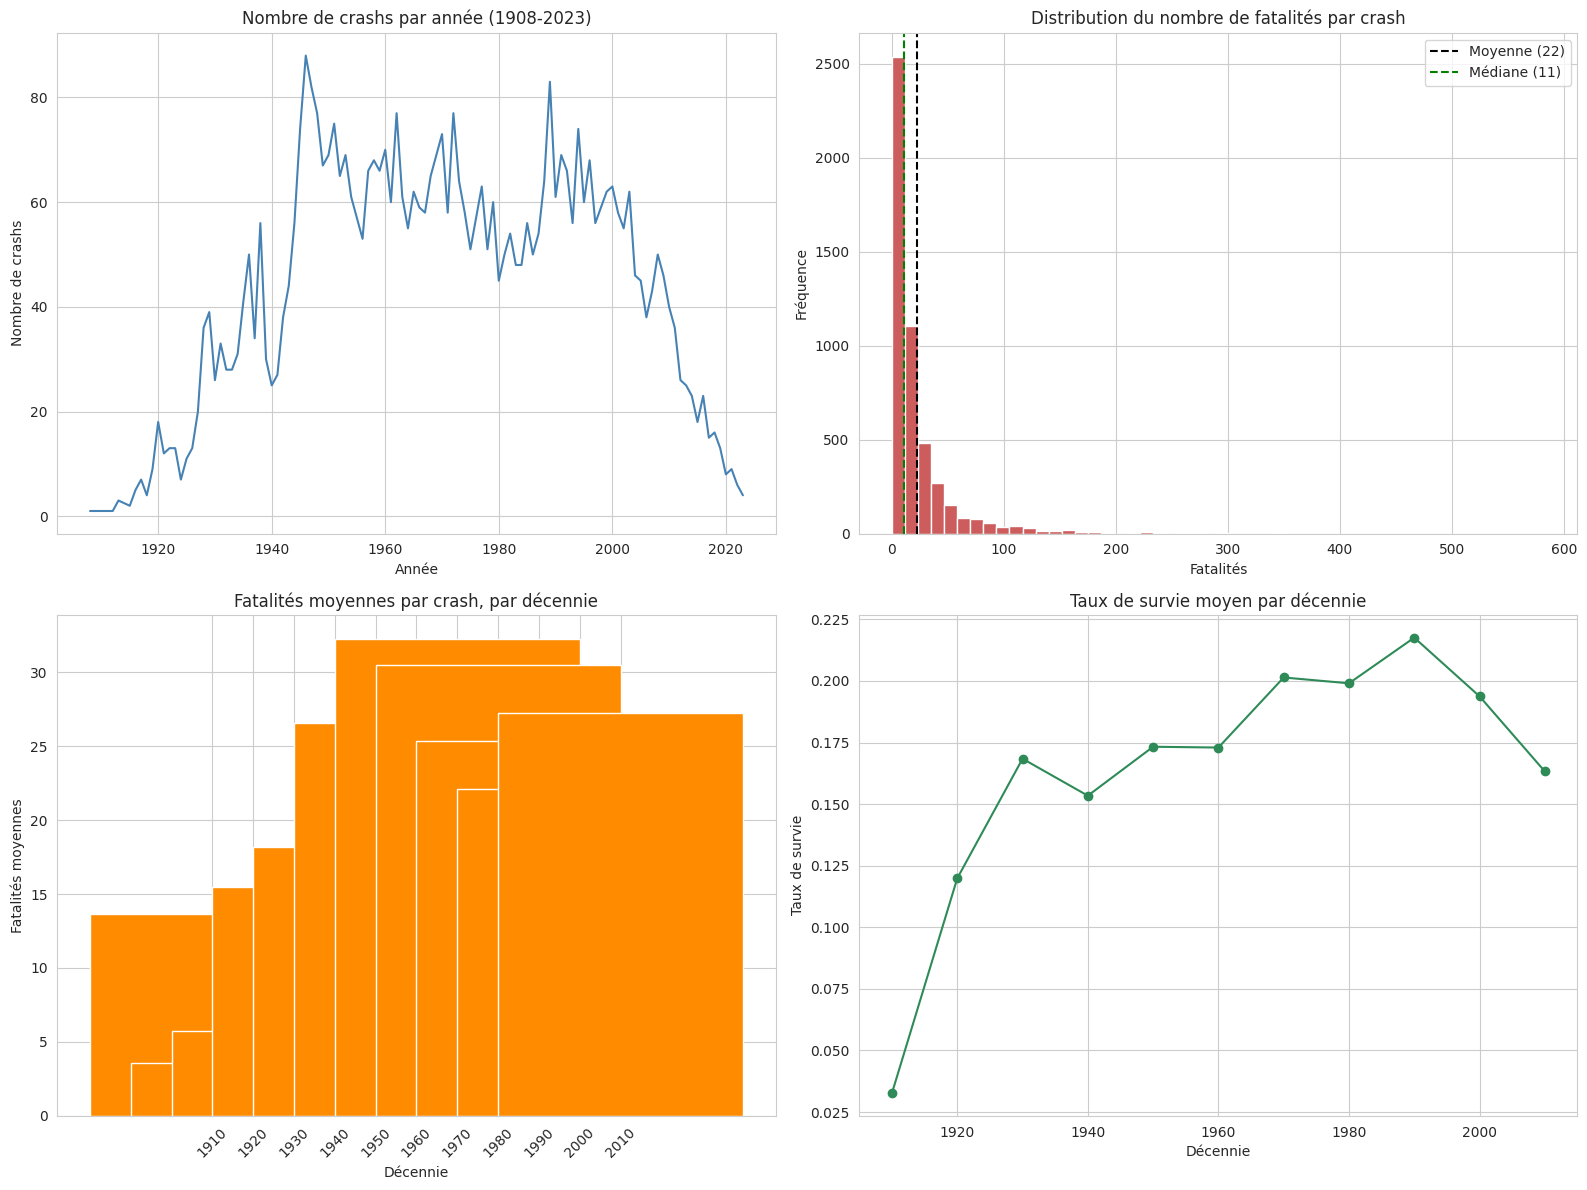

In [8]:
# ============================================================
# ÉTAPE 4 : Visualisations
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ------------------------------------------------------------
# 1) Évolution du nombre de crashs par année (time series)
# ------------------------------------------------------------
crashes_per_year = df.groupby('Year').size()
axes[0, 0].plot(crashes_per_year.index, crashes_per_year.values, color='steelblue')
axes[0, 0].set_title("Nombre de crashs par année (1908-2023)")
axes[0, 0].set_xlabel("Année")
axes[0, 0].set_ylabel("Nombre de crashs")

# ------------------------------------------------------------
# 2) Histogramme de la distribution des fatalités (avec asymétrie visible)
# ------------------------------------------------------------
axes[0, 1].hist(df['Fatalities'].dropna(), bins=50, color='indianred', edgecolor='white')
axes[0, 1].set_title("Distribution du nombre de fatalités par crash")
axes[0, 1].set_xlabel("Fatalités")
axes[0, 1].set_ylabel("Fréquence")
axes[0, 1].axvline(df['Fatalities'].mean(), color='black', linestyle='--', label=f"Moyenne ({df['Fatalities'].mean():.0f})")
axes[0, 1].axvline(df['Fatalities'].median(), color='green', linestyle='--', label=f"Médiane ({df['Fatalities'].median():.0f})")
axes[0, 1].legend()

# ------------------------------------------------------------
# 3) Fatalités moyennes par décennie (bar chart)
# ------------------------------------------------------------
mean_fatalities_decade = decades_to_compare.groupby('Decade', observed=True)['Fatalities'].mean()
axes[1, 0].bar(mean_fatalities_decade.index.astype(str), mean_fatalities_decade.values, color='darkorange', width=6)
axes[1, 0].set_title("Fatalités moyennes par crash, par décennie")
axes[1, 0].set_xlabel("Décennie")
axes[1, 0].set_ylabel("Fatalités moyennes")
axes[1, 0].tick_params(axis='x', rotation=45)

# ------------------------------------------------------------
# 4) Taux de survie moyen par décennie (line chart)
# ------------------------------------------------------------
survival_by_decade = df[~df['Decade'].isin([1900, 2020])].groupby('Decade', observed=True)['Survival_Rate'].mean()
axes[1, 1].plot(survival_by_decade.index, survival_by_decade.values, marker='o', color='seagreen')
axes[1, 1].set_title("Taux de survie moyen par décennie")
axes[1, 1].set_xlabel("Décennie")
axes[1, 1].set_ylabel("Taux de survie")

plt.tight_layout()
plt.show()

# Analysis of Airplane Crashes and Fatalities (1908–2023)

## 1. Introduction

This report analyzes the "Airplane Crashes and Fatalities up to 2023"
dataset, covering 4,998 recorded aviation accidents from 1908 to 2023. The
analysis applies Pandas, NumPy, and SciPy to clean the data, explore key
trends, test statistical hypotheses, and visualize findings regarding
fatalities and survival rates over time.

## 2. Data Import and Cleaning

The raw CSV required `latin-1` encoding (rather than the default UTF-8) due
to special characters in location names. Key cleaning steps:

- Converted the `Date` column (originally text) to proper `datetime` objects
  using `pd.to_datetime()` with `errors='coerce'`; no dates were lost (0
  invalid entries).
- Derived `Year` and `Decade` columns to support time-based aggregation.
- Computed `Survivors` and `Survival_Rate` as new features
  (`Survivors = Aboard - Fatalities`), with invalid ratios (outside [0,1])
  set to missing rather than dropped.
- Missing values were handled column-by-column rather than via a global
  `dropna()`, since columns like `Flight #` (73% missing) and `Route` (16%
  missing) are not needed for the core fatality/survival analysis, while
  `Aboard` and `Fatalities` — the key variables — have less than 1% missing
  data.

## 3. Exploratory Data Analysis

| Metric | Value |
|---|---|
| Total crashes | 4,998 |
| Total people aboard | 155,356 |
| Total fatalities | 111,644 |
| Overall survival rate | 28.14% |

The number of crashes per year rose from the early aviation era, peaked
between the 1950s and 1990s (~550–650 crashes per decade), then declined
sharply from the 2000s onward. **This decline should not be read as
"aviation became more dangerous and then safer" without normalizing for air
traffic volume** — global flight volume has grown enormously since the
1990s, so a falling raw crash count alongside rising traffic implies a much
larger improvement in safety *per flight* than the raw numbers suggest.

The years with the most crashes (1946, 1989, 1947) differ from the years
with the most total fatalities (1972, 1985, 1973) — a reminder that
frequency and severity are distinct dimensions of risk.

## 4. Statistical Analysis

### Distribution of Fatalities

| Statistic | Value |
|---|---|
| Mean | 22.37 |
| Median | 11.00 |
| Std deviation | 35.06 |
| Skewness | 4.61 |

A Shapiro-Wilk normality test confirmed that fatalities are **not normally
distributed** (statistic = 0.60, p ≈ 1.76 × 10⁻⁵⁵). The large gap between
mean and median, combined with a skewness of 4.61, indicates a strongly
right-skewed distribution: most crashes involve relatively few fatalities,
while a small number of catastrophic events (up to 583 fatalities) pull the
average upward. The median is therefore a more representative measure of a
"typical" crash than the mean.

### Survival Rate

The median survival rate across all crashes is **0%** — in over half of all
recorded crashes, there were no survivors at all. The mean survival rate
(18.15%) is pulled upward only by the subset of crashes that had at least
some survivors.

### Hypothesis Test: Fatalities Across Decades

A one-way ANOVA compared mean fatalities per crash across decades (excluding
the incomplete 1900s and 2020s decades):

| Metric | Value |
|---|---|
| F-statistic | 27.68 |
| p-value | 4.20 × 10⁻⁵² |

The result is highly statistically significant: average fatalities per
crash differ substantially across decades. However, this is best explained
by the **growing size of aircraft** over time (more passengers per flight)
rather than aviation becoming inherently "more lethal." Since the underlying
fatality distribution is non-normal, this result should ideally be
cross-checked with a non-parametric test (e.g., Kruskal-Wallis); given the
large sample size (n≈4,990), the ANOVA result is nonetheless considered
reasonably robust under the Central Limit Theorem.

## 5. Visualization Summary

- **Crashes per year**: a bell-shaped trend, rising through the mid-20th
  century and declining sharply after 2000.
- **Fatalities histogram**: visually confirms the right-skewed distribution,
  with mean and median lines clearly separated.
- **Mean fatalities by decade**: a clear upward trend, consistent with
  increasing aircraft passenger capacity over time.
- **Survival rate by decade**: very low (~3%) in the 1910s pioneering era,
  stabilizing around 17–22% from the 1950s onward — suggesting that once
  aviation matured past its earliest, most dangerous period, the survival
  rate in the event of a crash plateaued rather than steadily improving.

## 6. Discussion and Limitations

- **Survivorship interpretation**: this dataset only includes recorded
  crashes, not all flights — it cannot be used to estimate the actual risk
  of flying, only the characteristics of accidents that did occur.
- **Aircraft size confound**: differences in fatalities across decades
  partly reflect aircraft capacity growth, not necessarily a change in
  underlying safety. Normalizing by `Aboard` (i.e., using `Survival_Rate`)
  partially controls for this.
- **Missing data**: columns like `Flight #` and `Route` are too sparse to
  use reliably; conclusions are limited to variables with low missingness
  (Date, Aboard, Fatalities).
- **Non-normality**: most classical statistical tests assume normality;
  results here rely on either large-sample robustness (CLT) or should be
  validated with non-parametric alternatives for full rigor.

## 7. Conclusion

Aviation accident data from 1908–2023 reveals a strongly right-skewed
fatality distribution, with most crashes causing relatively few deaths and
a small number of catastrophic outliers driving the average upward. The
number of recorded crashes peaked mid-century and declined sharply in
recent decades — a trend that, combined with rising global air traffic,
likely reflects substantial improvements in aviation safety. Average
fatalities per crash differ significantly by decade (ANOVA, p < 0.001),
primarily reflecting the growth in aircraft passenger capacity. Survival
rates improved dramatically from aviation's earliest, most dangerous era,
then stabilized — suggesting that further safety gains are now reflected
more in reduced crash frequency than in improved outcomes when a crash does
occur.